In [72]:
from langgraph.graph import StateGraph, START, END;
from langchain_openai import ChatOpenAI;
from typing import TypedDict
from dotenv import load_dotenv

In [73]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundry_percentage: float

In [74]:
def calculate_sr(state: BatsmanState):
    sr = state["runs"] / state["balls"]

    return {'sr': sr}

In [75]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}

In [76]:
def calculate_boundry_percentage(state: BatsmanState):
    boundry_percentage = ((state['fours'] + state['sixes']) / state['balls'])*100

    return {'boundry_percentage': boundry_percentage}

In [77]:
def summary(state: BatsmanState):
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundry - {state['bpb']} \n
    Boundry Percent - {state['boundry_percentage']}
    """

    return {'summary': summary}

In [78]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundry_percentage', calculate_boundry_percentage)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundry_percentage')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundry_percentage', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()


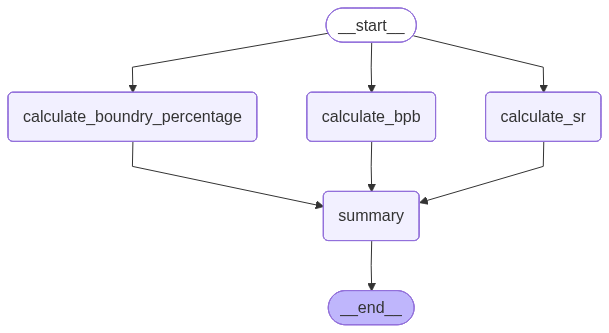

In [79]:
workflow

In [80]:
initial_state: BatsmanState = {
    'runs': 100,
    'balls': 50,
    'sixes': 6,
    'fours': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 4,
 'sixes': 6,
 'sr': 2.0,
 'bpb': 5.0,
 'boundry_percentage': 20.0}